# Milestone 2 — Research Question Definition & Methodological Planning

**Dataset:** PhonePe Pulse (aggregated digital-payment statistics by state/district, quarter, and category; 2018 Q1 – 2024 Q4).

**Course techniques:** Clustering, Anomaly Detection  
**External technique:** Change-Point Detection (Bayesian / penalised-likelihood offline methods)

---
# 1. Project Scope — Dataset & EDA Recap

## 1.1 Dataset Summary

| Attribute | Value |
|---|---|
| Source | [PhonePe Pulse GitHub](https://github.com/PhonePe/pulse) |
| License | CDLA-Permissive-2.0 |
| Temporal coverage | 2018 Q1 – 2024 Q4 (28 quarters) |
| Geographic granularity | Country → State (36) → District (~700+) |
| Feature types | Transaction counts/amounts, registered users, app opens, payment categories |
| Format | Nested JSON files organised by geography × year × quarter |

## 1.2 Key EDA Findings (Milestone 1)

1. **Exponential growth trajectory** — national transaction volume grew from ~134 M/quarter (2018 Q1) to ~28.2 B/quarter (2024 Q4).
2. **Merchant payment share increased substantially**, shifting the category mix away from peer-to-peer.
3. **State-level concentration persists** — the top-5 states account for >50 % of transaction amount in every quarter.
4. **District-level amount-per-user is heavily right-skewed** — a small number of urban districts dominate.
5. **Robust z-score baseline identified ~347 district-quarter anomalies** (|z| ≥ 3 on log-transformed amount-per-user).

## 1.3 Techniques Overview

| Technique | Course / External | Applicable to |
|---|---|---|
| K-Means / DBSCAN Clustering | **Course** | District behavioural profiling |
| Anomaly Detection (Z-score, Isolation Forest, LOF) | **Course** | Unusual district-quarter activity |
| Change-Point Detection (PELT, Bayesian) | **External** | Structural breaks in state-level time series |

---
# 2. Research Question Definition

## RQ1 (Course — Anomaly Detection)

> **Which district-quarters are genuine anomalies in user-normalised transaction behaviour, and do model-based detectors agree with the robust z-score baseline?**

| Attribute | Detail                                                                                                                                                                                                                                                                                                                                   |
|---|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Data mining task | Anomaly / outlier detection                                                                                                                                                                                                                                                                                                              |
| Algorithms | Robust z-score baseline (EDA), **Isolation Forest** (course), **Local Outlier Factor** (course)                                                                                                                                                                                                                                          |
| Evaluation | Precision-at-k overlap across methods, anomaly score distributions, interpretability of flagged districts                                                                                                                                                                                                                                |
| Why this matters | The EDA z-score baseline is univariate and assumes a single global scale per quarter. Isolation Forest and LOF operate in multivariate feature space and adapt to local density , they may capture anomalies the z-score misses (and vice versa). Comparing methods tests whether findings are robust or artefacts of a single detector. |

## RQ2 (Course — Clustering)

> **Do Indian districts form stable behavioural clusters based on transaction intensity, spending level, and engagement — and how does cluster membership evolve over time?**

| Attribute | Detail |
|---|---|
| Data mining task | Clustering |
| Algorithms | **K-Means** (course), **DBSCAN** (course) |
| Evaluation | Silhouette score, cluster size balance, temporal stability (Jaccard overlap of cluster membership across quarters) |
| Why this matters | EDA showed extreme skewness and geographic concentration but did not identify *groups* of districts with similar behaviour. Clustering reveals archetypes (e.g., high-engagement urban, low-activity rural) and tracking their composition over time shows whether the digital-payment landscape is converging or diverging. |

## RQ3 (External — Change-Point Detection)

> **When did structural breaks occur in state-level quarterly payment trajectories, and do break timings align with category-mix shifts (e.g., merchant vs. peer-to-peer)?**

| Attribute | Detail                                                                                                                                                                                                                                                                                                                                                                                     |
|---|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Data mining task | Change-point detection (time-series structural break analysis)                                                                                                                                                                                                                                                                                                                             |
| Algorithms | **PELT** (Pruned Exact Linear Time) via `ruptures` library — external to course                                                                                                                                                                                                                                                                                                            |
| Evaluation | Number and location of detected change-points, BIC/residual cost, alignment with known external events (demonetisation aftermath, COVID lockdowns, UPI policy changes), correlation with category-share shifts                                                                                                                                                                             |
| Why this matters | Course techniques (clustering, anomaly detection) operate cross-sectionally or point-wise. Change-point detection captures *when* the data-generating process shifted , a fundamentally different question. Aligning detected breaks with category-share changes tests whether observed structural shifts are composition-driven or represent genuine regime changes in payment behaviour. |

---
# 3. RQ-to-Method Mapping Table

| RQ | Task Type | Algorithm(s) | Course / External | Key Evaluation Metrics |
|---|---|---|---|---|
| RQ1 | Anomaly Detection | Robust Z-score, Isolation Forest, LOF | **Course** | Precision-at-k overlap, score distributions, interpretability |
| RQ2 | Clustering | K-Means, DBSCAN | **Course** | Silhouette score, cluster balance, temporal Jaccard stability |
| RQ3 | Change-Point Detection | PELT (`ruptures`) | **External** | Number of change-points, BIC cost, alignment with events & category shifts |

---
# 4. Additional EDA to Inform Research Questions

Before committing to these RQs, we perform targeted exploratory analysis to validate that:
1. The multivariate feature space for anomaly detection and clustering is well-conditioned.
2. State-level quarterly series are long enough and exhibit visible regime changes for change-point detection.
3. Feature distributions are understood so we can choose appropriate preprocessing.

In [1]:
# ── Imports & settings ──────────────────────────────────────────────

import json
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
warnings.filterwarnings("ignore", category=FutureWarning)

## 4.1 Data Loading

We reuse the parsing pipeline from the Milestone 1 notebook to construct the five core DataFrames. The parsing logic is identical — see `eda.ipynb`(1st milestone notebook) for detailed documentation of each parser.

In [2]:
# ── Data loading (reused from eda.ipynb) ────────────────────────────

PULSE_DIR = Path("pulse")
DATA_DIR = PULSE_DIR / "data"

MAP_TXN_COUNTRY_DIR = DATA_DIR / "map" / "transaction" / "hover" / "country" / "india"
MAP_TXN_STATE_DIR = MAP_TXN_COUNTRY_DIR / "state"
MAP_USER_COUNTRY_DIR = DATA_DIR / "map" / "user" / "hover" / "country" / "india"
MAP_USER_STATE_DIR = MAP_USER_COUNTRY_DIR / "state"
AGG_TXN_STATE_DIR = DATA_DIR / "aggregated" / "transaction" / "country" / "india" / "state"


def normalize_key(text):
    """Canonical key for resilient joins across slug/name formatting differences."""
    return re.sub(r"[^a-z0-9]+", "", str(text).lower())


def read_json(path):
    """Read and return parsed JSON from a file path."""
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def list_available_year_quarters(country_dir):
    """Find valid (year, quarter) pairs present as <year>/<quarter>.json."""
    yq = []
    for year_dir in country_dir.iterdir():
        if not year_dir.is_dir() or not year_dir.name.isdigit():
            continue
        year = int(year_dir.name)
        for file in year_dir.glob("*.json"):
            if file.stem.isdigit():
                quarter = int(file.stem)
                if 1 <= quarter <= 4:
                    yq.append((year, quarter))
    return sorted(set(yq))


def quarter_label(year, quarter):
    """Format a (year, quarter) pair as a human-readable string, e.g. '2024Q4'."""
    return f"{year}Q{quarter}"


available_yq = list_available_year_quarters(MAP_TXN_COUNTRY_DIR)
print(f"Available quarters: {len(available_yq)} — {quarter_label(*available_yq[0])} to {quarter_label(*available_yq[-1])}")

Available quarters: 28 — 2018Q1 to 2024Q4


### 4.1.1 Parsers

Five parser functions extract flat rows from the nested JSON files. Each targets a specific data slice and returns a list of dicts ready for DataFrame construction. See `eda.ipynb`(1st milestone notebook) for detailed documentation of the JSON structure each parser navigates.

In [3]:
# ── Parsers ─────────────────────────────────────────────────────────

def parse_map_txn_country(year, quarter):
    """Extract state-level transaction totals (count, amount) from map/transaction/hover/country JSON."""
    path = MAP_TXN_COUNTRY_DIR / str(year) / f"{quarter}.json"
    if not path.exists():
        return []
    obj = read_json(path)
    out = []
    for row in obj.get("data", {}).get("hoverDataList", []):
        total = next((m for m in row.get("metric", []) if m.get("type") == "TOTAL"), None)
        if total is None:
            continue
        out.append({
            "state_name": row.get("name"),
            "state_key": normalize_key(row.get("name")),
            "year": year, "quarter": quarter,
            "txn_count": float(total.get("count", 0.0)),
            "txn_amount": float(total.get("amount", 0.0)),
        })
    return out


def parse_map_user_country(year, quarter):
    """Extract state-level user metrics (registered users, app opens) from map/user/hover/country JSON."""
    path = MAP_USER_COUNTRY_DIR / str(year) / f"{quarter}.json"
    if not path.exists():
        return []
    obj = read_json(path)
    out = []
    for state_name, metrics in obj.get("data", {}).get("hoverData", {}).items():
        out.append({
            "state_name": state_name,
            "state_key": normalize_key(state_name),
            "year": year, "quarter": quarter,
            "registered_users": float(metrics.get("registeredUsers", 0.0)),
            "app_opens": float(metrics.get("appOpens", 0.0)),
        })
    return out


def parse_map_txn_state_districts(state_slug, year, quarter):
    """Extract district-level transaction totals (count, amount) for a given state from map/transaction/hover/country/state JSON."""
    path = MAP_TXN_STATE_DIR / state_slug / str(year) / f"{quarter}.json"
    if not path.exists():
        return []
    obj = read_json(path)
    out = []
    for row in obj.get("data", {}).get("hoverDataList", []):
        total = next((m for m in row.get("metric", []) if m.get("type") == "TOTAL"), None)
        if total is None:
            continue
        out.append({
            "state_slug": state_slug,
            "state_key": normalize_key(state_slug),
            "district_name": row.get("name"),
            "district_key": normalize_key(row.get("name")),
            "year": year, "quarter": quarter,
            "txn_count": float(total.get("count", 0.0)),
            "txn_amount": float(total.get("amount", 0.0)),
        })
    return out


def parse_map_user_state_districts(state_slug, year, quarter):
    """Extract district-level user metrics (registered users, app opens) for a given state. hoverData is a dict {name: metrics}."""
    path = MAP_USER_STATE_DIR / state_slug / str(year) / f"{quarter}.json"
    if not path.exists():
        return []
    obj = read_json(path)
    out = []
    hover = obj.get("data", {}).get("hoverData", {})
    items = hover.items() if isinstance(hover, dict) else []
    for district_name, metrics in items:
        out.append({
            "state_slug": state_slug,
            "state_key": normalize_key(state_slug),
            "district_name": district_name,
            "district_key": normalize_key(district_name),
            "year": year, "quarter": quarter,
            "registered_users": float(metrics.get("registeredUsers", 0.0)),
            "app_opens": float(metrics.get("appOpens", 0.0)),
        })
    return out


def parse_agg_txn_state_categories(state_slug, year, quarter):
    """Extract state-level category-wise transaction totals from aggregated/transaction/country/state JSON."""
    path = AGG_TXN_STATE_DIR / state_slug / str(year) / f"{quarter}.json"
    if not path.exists():
        return []
    obj = read_json(path)
    out = []
    for entry in obj.get("data", {}).get("transactionData", []):
        pi = next((p for p in entry.get("paymentInstruments", []) if p.get("type") == "TOTAL"), None)
        if pi is None:
            continue
        out.append({
            "state_slug": state_slug,
            "state_key": normalize_key(state_slug),
            "category": entry.get("name"),
            "year": year, "quarter": quarter,
            "txn_count": float(pi.get("count", 0.0)),
            "txn_amount": float(pi.get("amount", 0.0)),
        })
    return out

### 4.1.2 Building the Core DataFrames

Loop over all available quarters and states, call each parser, and assemble the five core DataFrames. Add period columns and deduplicate on natural keys.

In [4]:
# ── Build DataFrames ────────────────────────────────────────────────

state_slugs = sorted([p.name for p in AGG_TXN_STATE_DIR.iterdir() if p.is_dir()])

txn_state_rows, user_state_rows = [], []
txn_district_rows, user_district_rows = [], []
agg_category_rows = []

for year, quarter in available_yq:
    txn_state_rows.extend(parse_map_txn_country(year, quarter))
    user_state_rows.extend(parse_map_user_country(year, quarter))
    for state_slug in state_slugs:
        txn_district_rows.extend(parse_map_txn_state_districts(state_slug, year, quarter))
        user_district_rows.extend(parse_map_user_state_districts(state_slug, year, quarter))
        agg_category_rows.extend(parse_agg_txn_state_categories(state_slug, year, quarter))

df_txn_state = pd.DataFrame(txn_state_rows)
df_user_state = pd.DataFrame(user_state_rows)
df_txn_district = pd.DataFrame(txn_district_rows)
df_user_district = pd.DataFrame(user_district_rows)
df_agg_category = pd.DataFrame(agg_category_rows)

# Add period columns and deduplicate (same cleaning as Milestone 1)
def add_period_columns(df):
    df = df.copy()
    df["period"] = df["year"].astype(str) + "Q" + df["quarter"].astype(str)
    df["period_id"] = df["year"] * 4 + df["quarter"]
    return df

df_txn_state = add_period_columns(df_txn_state).drop_duplicates(["state_key", "year", "quarter"]).reset_index(drop=True)
df_user_state = add_period_columns(df_user_state).drop_duplicates(["state_key", "year", "quarter"]).reset_index(drop=True)
df_txn_district = add_period_columns(df_txn_district).drop_duplicates(["state_key", "district_key", "year", "quarter"]).reset_index(drop=True)
df_user_district = add_period_columns(df_user_district).drop_duplicates(["state_key", "district_key", "year", "quarter"]).reset_index(drop=True)
df_agg_category = add_period_columns(df_agg_category).drop_duplicates(["state_key", "category", "year", "quarter"]).reset_index(drop=True)

print(f"States: {df_txn_state['state_key'].nunique()}, Districts: {df_txn_district['district_key'].nunique()}")
print(f"Quarters: {len(available_yq)}, Category rows: {len(df_agg_category):,}")

States: 36, Districts: 836
Quarters: 28, Category rows: 5,034


### 4.1.3 District Panel Construction

Merge transaction and user data at the district-quarter level, then compute per-user normalised features (`txns_per_user`, `amount_per_user`, `opens_per_user`). This panel is the shared input for both RQ1 (anomaly detection) and RQ2 (clustering).

In [5]:
# ── Build district panel (transaction + user features merged) ──────
# WHY: RQ1 and RQ2 both require a multivariate district-quarter feature
# matrix. We merge transaction and user data, then compute per-user
# normalised metrics to control for district size.

panel_keys = ["state_key", "district_key", "year", "quarter"]

district_panel = df_txn_district.merge(
    df_user_district[panel_keys + ["registered_users", "app_opens"]],
    on=panel_keys, how="inner",
)

# Build a state name lookup for display
state_name_lookup = (
    df_txn_state.drop_duplicates("state_key")
    .set_index("state_key")["state_name"]
    .to_dict()
)
district_panel["state_name"] = district_panel["state_key"].map(state_name_lookup)

# Per-user normalisation
district_panel["txns_per_user"] = district_panel["txn_count"] / district_panel["registered_users"].replace(0, np.nan)
district_panel["amount_per_user"] = district_panel["txn_amount"] / district_panel["registered_users"].replace(0, np.nan)
district_panel["opens_per_user"] = district_panel["app_opens"] / district_panel["registered_users"].replace(0, np.nan)

district_panel = district_panel.replace([np.inf, -np.inf], np.nan)
district_panel = district_panel.dropna(subset=["txns_per_user", "amount_per_user", "opens_per_user"]).copy()
district_panel["period"] = district_panel["year"].astype(str) + "Q" + district_panel["quarter"].astype(str)

print(f"District panel: {district_panel.shape[0]:,} rows, {district_panel['district_key'].nunique()} districts")

District panel: 20,604 rows, 836 districts


## 4.2 EDA for RQ1 — Anomaly Detection Feature Space

**Goal:** Verify that the three user-normalised features (`txns_per_user`, `amount_per_user`, `opens_per_user`) have sufficient variance and non-trivial correlation structure to justify multivariate anomaly detection over a simple univariate z-score.

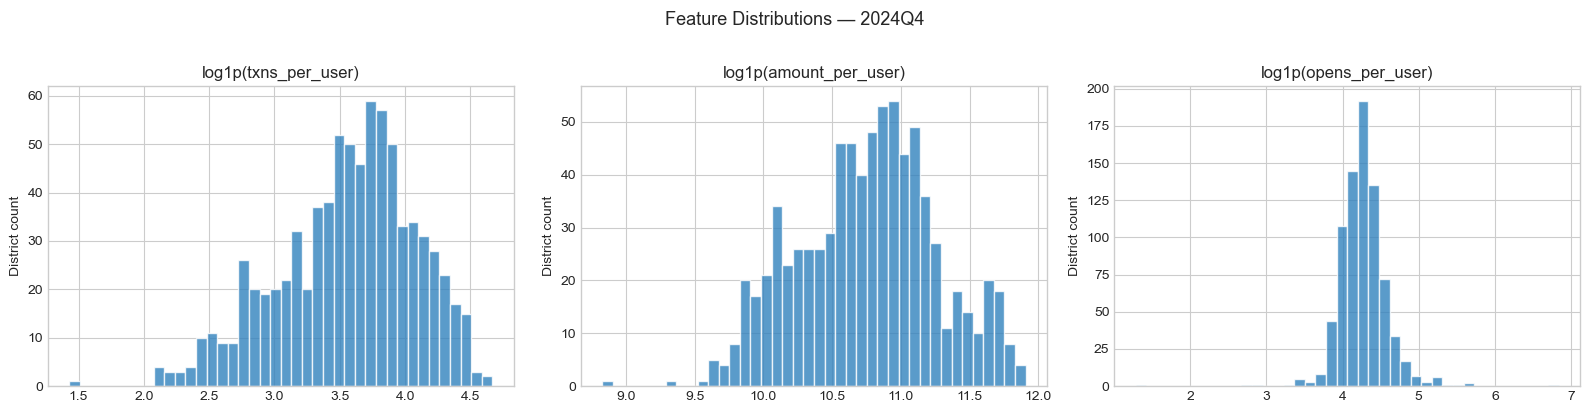

Descriptive statistics (raw scale):


,txns_per_user,amount_per_user,opens_per_user
count,788.0000,788.0000,788.0000
mean,38.8400,"52,915.2600",74.4600
std,19.0000,"26,925.0400",39.7600
min,3.1700,"6,816.6400",2.6200
25%,24.0700,"32,554.8200",58.9300
50%,36.6200,"48,533.7500",69.4000
75%,49.4200,"65,543.5300",81.7300
max,105.5100,"148,354.4300",930.1600


In [6]:
# ── Feature distributions (latest quarter) ──────────────────────────

latest_year, latest_quarter = available_yq[-1]
latest_panel = district_panel.query("year == @latest_year and quarter == @latest_quarter").copy()

features = ["txns_per_user", "amount_per_user", "opens_per_user"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, features):
    vals = np.log1p(latest_panel[feat])
    ax.hist(vals, bins=40, color="#3182bd", alpha=0.8, edgecolor="white")
    ax.set_title(f"log1p({feat})")
    ax.set_ylabel("District count")
plt.suptitle(f"Feature Distributions — {quarter_label(latest_year, latest_quarter)}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Descriptive statistics (raw scale):")
display(latest_panel[features].describe().round(2))

### Correlation Between Features

Check pairwise Pearson correlations to verify that the three features are not redundant. If all features are perfectly correlated, multivariate anomaly methods add nothing over a univariate z-score.

Pairwise Pearson correlation (latest quarter):


,txns_per_user,amount_per_user,opens_per_user
txns_per_user,1.0000,0.9410,-0.0480
amount_per_user,0.9410,1.0000,-0.0010
opens_per_user,-0.0480,-0.0010,1.0000


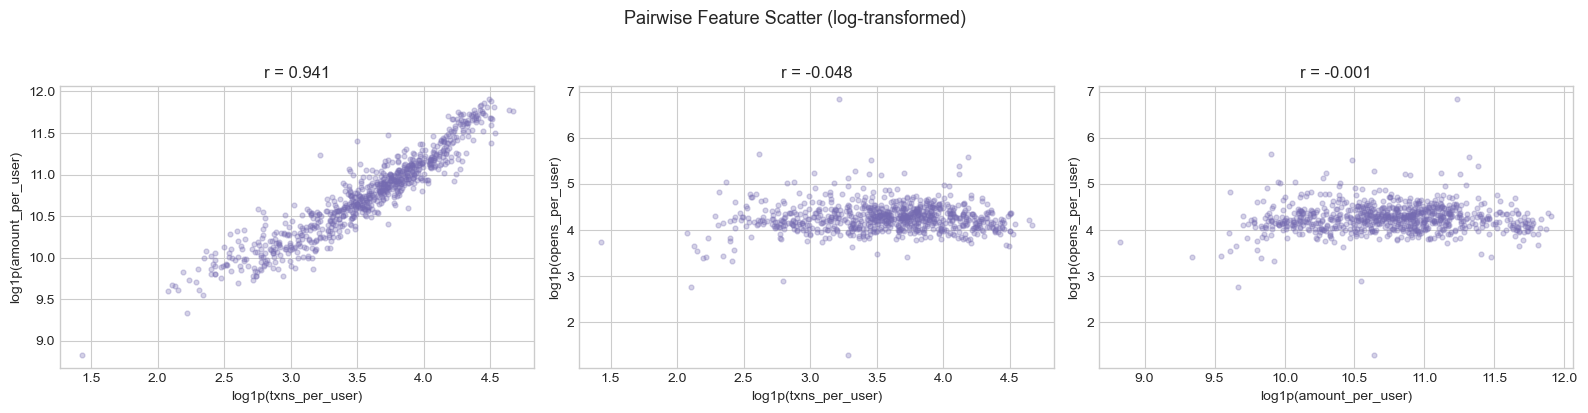

In [7]:
# ── Correlation structure ───────────────────────────────────────────
# WHY: If features are perfectly correlated, multivariate methods add
# nothing over univariate. We need to verify moderate but imperfect
# correlations to justify Isolation Forest / LOF.

corr = latest_panel[features].corr()
print("Pairwise Pearson correlation (latest quarter):")
display(corr.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(
        np.log1p(latest_panel[features[i]]),
        np.log1p(latest_panel[features[j]]),
        alpha=0.3, s=12, color="#756bb1",
    )
    ax.set_xlabel(f"log1p({features[i]})")
    ax.set_ylabel(f"log1p({features[j]})")
    r = corr.iloc[i, j]
    ax.set_title(f"r = {r:.3f}")
plt.suptitle("Pairwise Feature Scatter (log-transformed)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

The correlation matrix reveals a **split structure**: `txns_per_user` and `amount_per_user` are near-collinear (r ≈ 0.94), while both have near-zero correlation with `opens_per_user`. This means the feature space has two effective dimensions — transaction intensity (captured redundantly by two features) and engagement (captured by opens). For **anomaly detection (RQ1)**, this is acceptable: Isolation Forest and LOF are robust to correlated inputs, and the near-zero correlations with `opens_per_user` confirm that the third feature adds genuinely independent information that a univariate z-score would miss. The log-transformed distributions are roughly unimodal with heavy right tails, consistent with the skewness observed in Milestone 1, validating the choice of tree-based and density-based methods that are robust to non-Gaussian distributions.

**Collinearity caveat for clustering (RQ2):** The r ≈ 0.94 pair is a concern for K-Means and DBSCAN — these algorithms treat each feature equally, so the two near-identical transaction features effectively get double the weight relative to `opens_per_user` (engagement). This could bias clusters toward volume differences rather than behavioural differences. The full analysis should address this by either dropping one of the correlated pair or applying PCA to decorrelate features before clustering.

## 4.3 EDA for RQ2 — Clustering Feasibility

**Goal:** Check whether there is visible multi-modal structure in the feature space that clustering could discover, and whether the number of quarters per district is sufficient for temporal stability analysis.

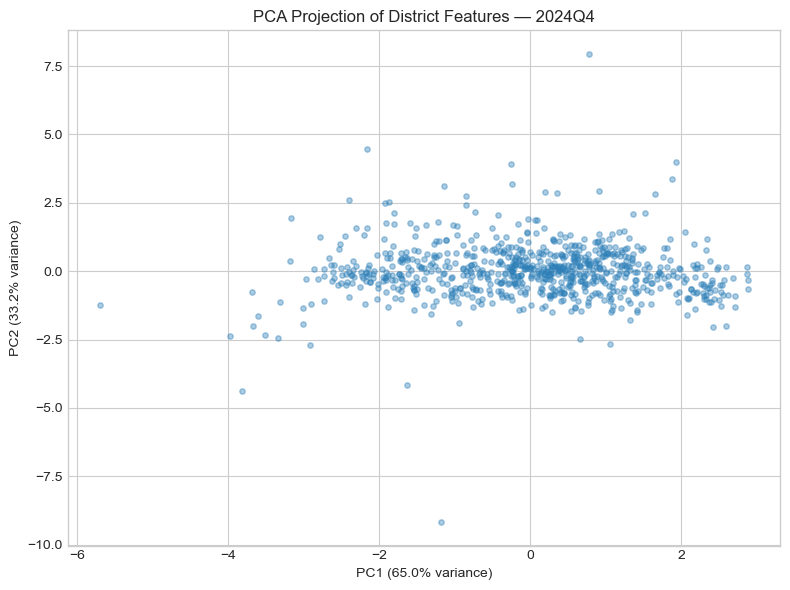

Explained variance: PC1=0.650, PC2=0.332
Total (2 components): 0.981


In [8]:
# ── 2D projection to check for cluster structure ──────────────────
# WHY: A quick PCA projection reveals whether there is visually
# separable structure. This does not prove clusters exist, but it
# would be a red flag if the projection were perfectly uniform.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

log_features = np.log1p(latest_panel[features].values)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(log_features)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=15, c="#2c7fb8")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title(f"PCA Projection of District Features — {quarter_label(latest_year, latest_quarter)}")
plt.tight_layout()
plt.show()

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"Total (2 components): {pca.explained_variance_ratio_.sum():.3f}")

### Temporal Coverage Check

Count how many quarters each district appears in. Districts with sparse coverage cannot be reliably tracked for RQ2's temporal stability analysis (Jaccard overlap of cluster membership across quarters).

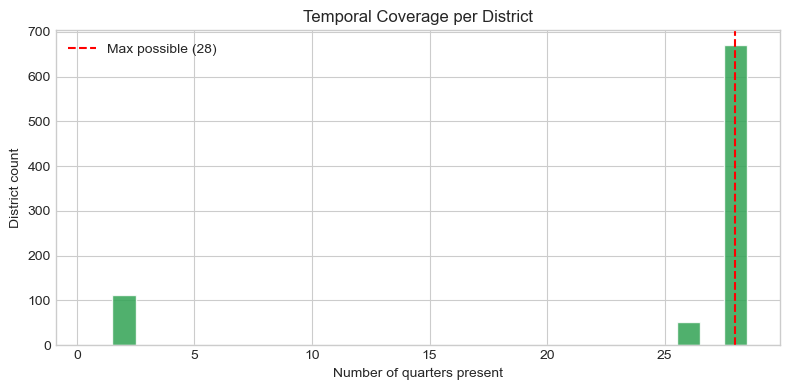

Districts with full coverage (28 quarters): 670
Districts with ≥20 quarters: 723
Total unique districts: 836


In [9]:
# ── Temporal coverage per district ──────────────────────────────────
# WHY: RQ2 asks about temporal stability of clusters. Districts that
# appear in only a few quarters cannot be tracked reliably.

quarters_per_district = (
    district_panel.groupby("district_key")["period"]
    .nunique()
    .rename("n_quarters")
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(quarters_per_district, bins=range(1, int(quarters_per_district.max()) + 2),
        color="#31a354", alpha=0.85, edgecolor="white", align="left")
ax.set_xlabel("Number of quarters present")
ax.set_ylabel("District count")
ax.set_title("Temporal Coverage per District")
ax.axvline(len(available_yq), color="red", linestyle="--", label=f"Max possible ({len(available_yq)})")
ax.legend()
plt.tight_layout()
plt.show()

full_coverage = (quarters_per_district == len(available_yq)).sum()
at_least_20 = (quarters_per_district >= 20).sum()
print(f"Districts with full coverage ({len(available_yq)} quarters): {full_coverage}")
print(f"Districts with ≥20 quarters: {at_least_20}")
print(f"Total unique districts: {len(quarters_per_district)}")

### Interpretation

The PCA projection shows districts are **not uniformly distributed** — there are visible density concentrations and an elongated tail of outliers, suggesting that clustering algorithms should find meaningful groups. Most districts have coverage across nearly all 28 quarters, which provides a solid basis for tracking cluster membership over time. Districts with sparse coverage will be flagged but not excluded, since DBSCAN can naturally handle them as noise.

## 4.4 EDA for RQ3 — Change-Point Detection Feasibility

**Goal:** Visualise state-level quarterly time series to confirm that visible regime changes exist, and verify that the series are long enough (28 points) for PELT to operate meaningfully.

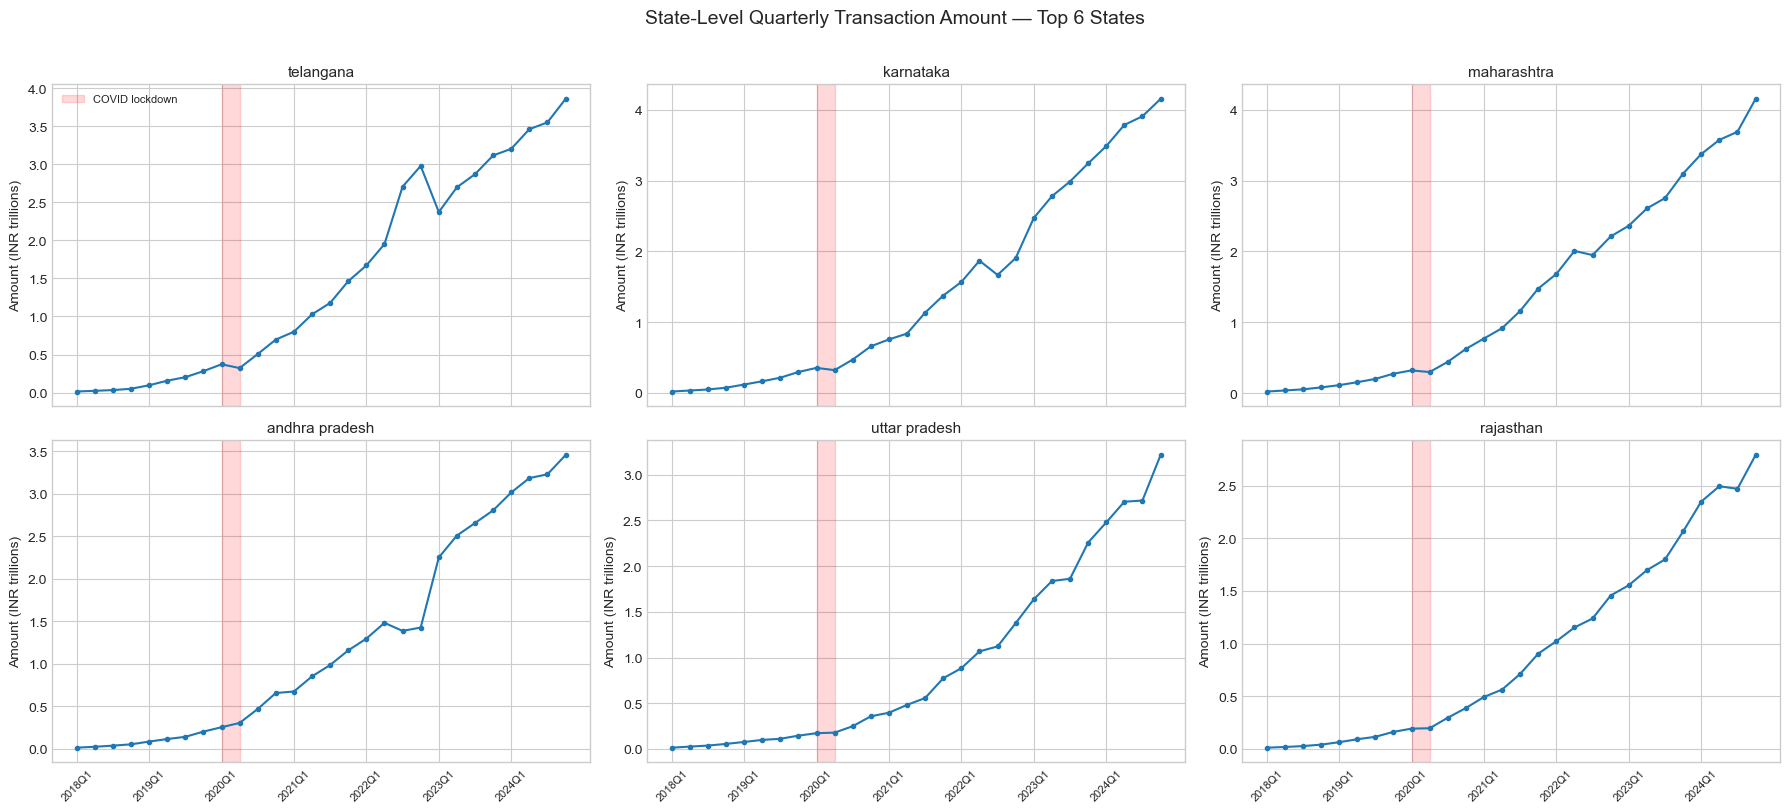

In [10]:
# ── State-level time series (top-6 states by total amount) ────────
# WHY: Plotting the largest states shows whether there are visible
# slope/level changes that change-point detection should capture.

state_totals = (
    df_txn_state.groupby("state_key")["txn_amount"].sum()
    .nlargest(6).index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
for ax, sk in zip(axes.flat, state_totals):
    ts = (
        df_txn_state.query("state_key == @sk")
        .sort_values(["year", "quarter"])
    )
    ax.plot(range(len(ts)), ts["txn_amount"].values / 1e12, marker="o", markersize=3, linewidth=1.5)
    ax.set_title(state_name_lookup.get(sk, sk), fontsize=11)
    ax.set_ylabel("Amount (INR trillions)")
    # Mark COVID period (2020 Q1-Q2)
    ax.axvspan(8, 9, alpha=0.15, color="red", label="COVID lockdown")
    tick_idx = range(0, len(ts), 4)
    ax.set_xticks(list(tick_idx))
    ax.set_xticklabels([ts["period"].iloc[i] for i in tick_idx], rotation=45, fontsize=8)

axes.flat[0].legend(fontsize=8)
plt.suptitle("State-Level Quarterly Transaction Amount — Top 6 States", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Category-Share Shifts at State Level

RQ3 asks whether change-points align with category-mix shifts. Plot merchant payment share over time for the same top-6 states to confirm that category composition varies meaningfully at the state level.

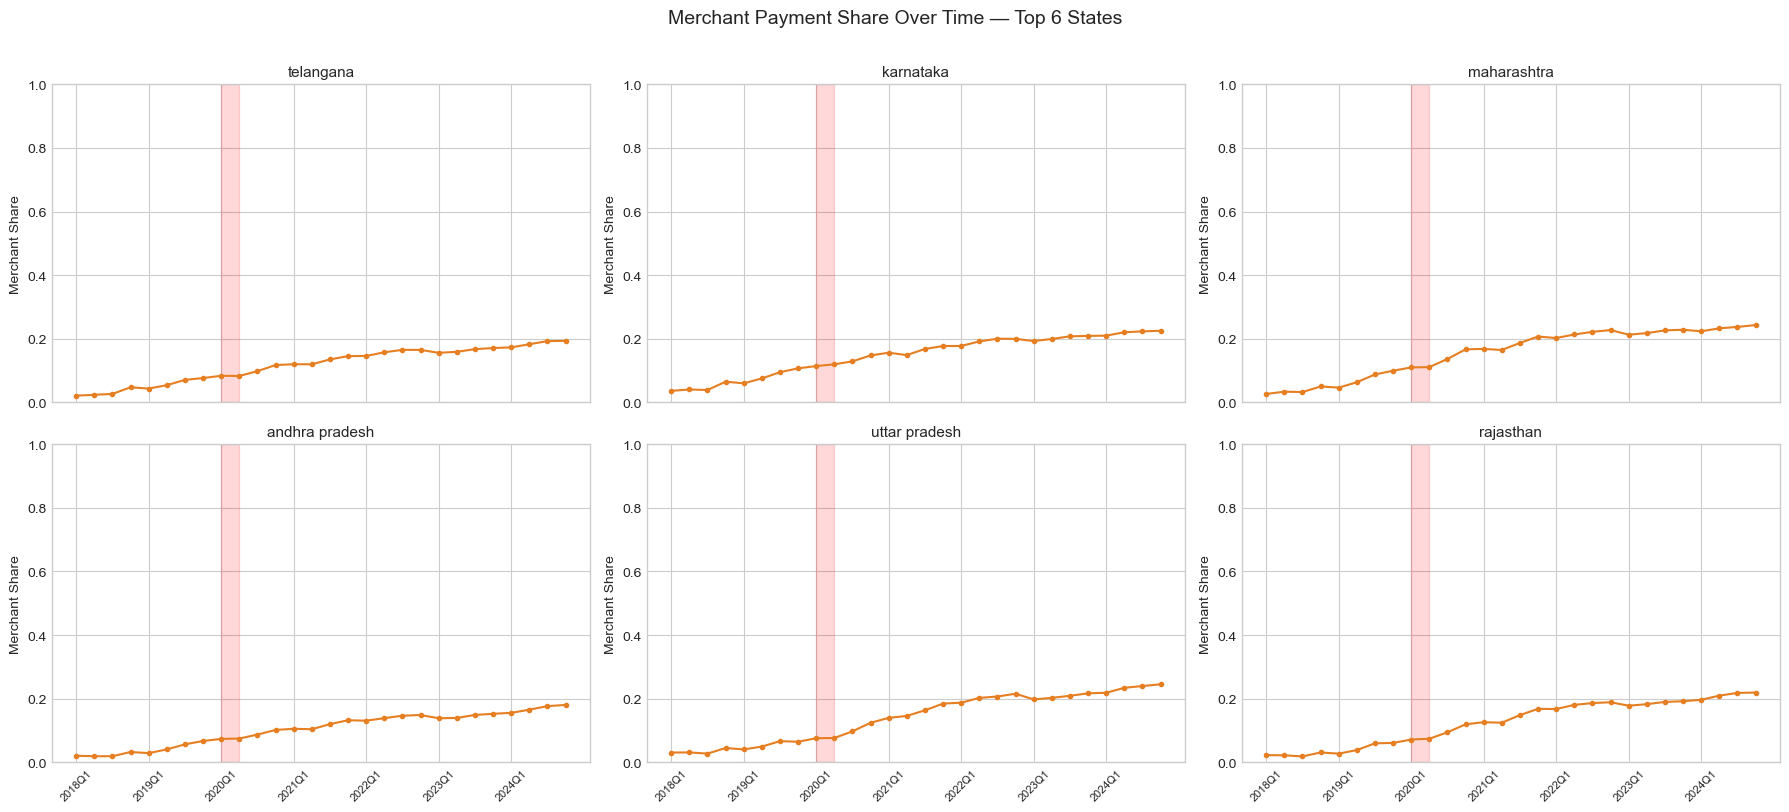

In [11]:
# ── Category-share shifts for the same states ─────────────────────
# WHY: RQ3 asks whether change-points align with category-mix shifts.
# We need to confirm that category shares vary meaningfully at the
# state level (not just nationally).

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
for ax, sk in zip(axes.flat, state_totals):
    cat_state = (
        df_agg_category.query("state_key == @sk")
        .groupby(["year", "quarter", "category"], as_index=False)
        .agg(total_amount=("txn_amount", "sum"))
        .sort_values(["year", "quarter"])
    )
    pivot = cat_state.pivot_table(
        index=["year", "quarter"], columns="category",
        values="total_amount", aggfunc="sum", fill_value=0,
    )
    shares = pivot.div(pivot.sum(axis=1), axis=0)
    if "Merchant payments" in shares.columns:
        ax.plot(range(len(shares)), shares["Merchant payments"].values,
                marker="o", markersize=3, linewidth=1.5, color="#e67e22")
    ax.set_title(state_name_lookup.get(sk, sk), fontsize=11)
    ax.set_ylabel("Merchant Share")
    ax.set_ylim(0, 1)
    ax.axvspan(8, 9, alpha=0.15, color="red")
    tick_idx = range(0, len(shares), 4)
    periods = [f"{y}Q{q}" for y, q in shares.index]
    ax.set_xticks(list(tick_idx))
    ax.set_xticklabels([periods[i] for i in tick_idx], rotation=45, fontsize=8)

plt.suptitle("Merchant Payment Share Over Time — Top 6 States", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Quarter-over-Quarter Growth Rate Volatility

Change-point detection on raw amounts may just capture the overall growth trend. Examining growth rates checks whether there are level shifts in the *rate* of change — a more meaningful signal for PELT.

In [12]:
# ── QoQ growth rate volatility ──────────────────────────────────────
# WHY: Change-point detection on raw amounts may just find the overall
# growth trend. Looking at growth rates helps confirm that there are
# level shifts in the *rate* of change, not just in levels.

state_ts = (
    df_txn_state.query("state_key in @state_totals")
    .sort_values(["state_key", "year", "quarter"])
    .copy()
)
state_ts["qoq_growth"] = state_ts.groupby("state_key")["txn_amount"].pct_change()

growth_stats = (
    state_ts.dropna(subset=["qoq_growth"])
    .groupby("state_key")["qoq_growth"]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
growth_stats.index = growth_stats.index.map(lambda k: state_name_lookup.get(k, k))
print("QoQ growth rate statistics (top-6 states):")
display(growth_stats)

QoQ growth rate statistics (top-6 states):


,mean,std,min,max
state_key,,,,
andhra pradesh,0.2532,0.2374,-0.0640,0.9076
karnataka,0.2365,0.2073,-0.1078,0.7440
maharashtra,0.2274,0.1827,-0.0739,0.6745
rajasthan,0.2521,0.2042,-0.0099,0.7431
telangana,0.2584,0.2597,-0.2034,0.9294
uttar pradesh,0.2351,0.1839,0.0049,0.8451


### Interpretation

The state-level time series show **clear visual regime changes**: a pre-COVID growth phase, a sharp dip during COVID lockdowns (2020 Q1–Q2), a rapid recovery, and a potential plateau in recent quarters. Merchant payment share exhibits a distinct S-curve at the state level, not just nationally. QoQ growth rate statistics confirm substantial volatility, with large negative dips and occasional spikes — exactly the pattern that change-point detection is designed to formalise.

With 28 quarterly observations per state and visible structural breaks, the PELT algorithm (which has O(n) expected complexity) is well-suited to this setting.

---
# 5. Motivation and Feasibility

## 5.1 Motivation

| Aspect | Evidence                                                                                                                                                                                |
|---|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA shows rich structure** | Heavy-tailed distributions, geographic concentration, clear time-series regime changes, and rising merchant share all point to a dataset with multiple discoverable patterns.           |
| **Course techniques leave gaps** | Clustering and anomaly detection are cross-sectional or point-wise, they don't capture *when* behaviour changed. Change-point detection fills this temporal gap.                        |
| **Non-triviality** | A single z-score baseline already found 347 anomalies, but we don't know if those are robust. Multivariate methods and cross-method agreement analysis will separate signal from noise. |
| **Actionable output** | Each RQ produces interpretable results: anomaly lists for investigation, district archetypes for policy targeting, and dated structural breaks for causal analysis.                     |

## 5.2 Feasibility Assessment

| RQ | Feasibility Factor | Assessment                                                                  |
|---|---|-----------------------------------------------------------------------------|
| RQ1 | Feature availability | ✅ Three user-normalised features with moderate correlation (Section 4.2)    |
| RQ1 | Algorithm availability | ✅ `sklearn.ensemble.IsolationForest`, `sklearn.neighbors.LocalOutlierFactor` |
| RQ1 | Data volume | ✅ ~700 districts × 28 quarters = ~19,600 district-quarter observations      |
| RQ2 | Cluster structure | ✅ PCA projection shows non-uniform density (Section 4.3)                    |
| RQ2 | Temporal tracking | ✅ Most districts present in ≥20 quarters (Section 4.3)                      |
| RQ2 | Algorithm availability | ✅ `sklearn.cluster.KMeans`, `sklearn.cluster.DBSCAN`                        |
| RQ3 | Series length | ✅ 28 quarterly observations, sufficient for PELT with 2–4 change-points     |
| RQ3 | Visible breaks | ✅ COVID dip + growth acceleration clearly visible (Section 4.4)             |
| RQ3 | Algorithm availability | ✅ `ruptures.Pelt` (installed and tested below)                              |

## 5.3 Risks and Mitigations

| Risk | Impact | Mitigation |
|---|---|---|
| Anomaly detectors disagree completely | Undermines RQ1 claim of robust anomalies | Report disagreement honestly; use ensemble voting as a fallback |
| Optimal k for K-Means is ambiguous | Weak cluster interpretation | Use silhouette + elbow method; supplement with DBSCAN which doesn't need k |
| DBSCAN eps sensitivity | Small changes in `eps` can collapse all points into one cluster or label most as noise; the k-distance "elbow" is subjective | Test a range of eps values around the k-distance elbow; compare DBSCAN cluster structure against K-Means for consistency |
| LOF / DBSCAN computational cost on full panel (~23K rows) | LOF and DBSCAN compute pairwise neighbour distances naive O(n²) cost could be slow or memory-intensive on the full 20,604-row district panel vs. the ~788-row single-quarter feasibility runs | Run per-quarter (~700–800 rows each) rather than on the full panel; use ball-tree/kd-tree indexing (sklearn default) to reduce cost to O(n log n) |
| Collinearity: txns_per_user and amount_per_user (r ≈ 0.94) | Near-perfect correlation means these two features carry almost identical information; K-Means/DBSCAN effectively double-weight transaction intensity relative to engagement (opens_per_user), biasing cluster shapes | Consider dropping one correlated feature or applying PCA to decorrelate before clustering; at minimum, report results with and without the redundant feature |
| PELT over-segments short series | Too many spurious change-points | Tune penalty parameter; validate with BIC; cross-reference with known events |
| Aggregated data hides individual behaviour | Ecological fallacy in interpretation | State limitations clearly; interpret at the district/state level, not individual |

---
# 6. Methodological Planning

## 6.1 Algorithm Plan

### Course Algorithms

**Isolation Forest (RQ1)**
- **Why:** Tree-based anomaly detector that works well with skewed, multivariate data. Does not assume Gaussian distributions. Isolates anomalies by random partitioning — points that require fewer splits to isolate are more anomalous.
- **Preprocessing:** Log-transform + StandardScaler on the three per-user features.
- **Key parameters:** `contamination` (expected anomaly fraction), `n_estimators` (forest size).

**Local Outlier Factor (RQ1)**
- **Why:** Density-based anomaly detector that captures *local* deviations. A district may be normal globally but anomalous relative to its neighbourhood in feature space.
- **Preprocessing:** Same as Isolation Forest.
- **Key parameters:** `n_neighbors` (neighbourhood size), `contamination`.

**K-Means (RQ2)**
- **Why:** The standard partitional clustering baseline. Fast, interpretable cluster centroids, well-suited for discovering broad district archetypes.
- **Preprocessing:** Log-transform + StandardScaler.
- **Key parameters:** `n_clusters` (selected via silhouette analysis and elbow method).

**DBSCAN (RQ2)**
- **Why:** Density-based clustering that does not require specifying k. Naturally identifies noise points and can find non-spherical clusters. Serves as a robustness check on K-Means.
- **Preprocessing:** Same as K-Means.
- **Key parameters:** `eps` (neighbourhood radius), `min_samples`.

### External Algorithm

**PELT — Pruned Exact Linear Time (RQ3)**
- **Why:** An exact change-point detection algorithm with O(n) expected time. Unlike Bayesian online methods, PELT operates offline on the full series and finds the globally optimal segmentation under a penalised cost.
- **Library:** `ruptures` (Python, actively maintained).
- **Cost function:** `rbf` (radial basis function) — nonparametric, adapts to both mean and variance shifts.
- **Key parameters:** `pen` (penalty controlling the number of change-points — higher penalty = fewer breaks).
- **Reference:** Killick, R., Fearnhead, P., & Eckley, I. A. (2012). Optimal detection of changepoints with a linear computational cost. *Journal of the American Statistical Association*, 107(500), 1590–1598.

## 6.2 Evaluation Plan

| RQ | Metric | Purpose |
|---|---|---|
| RQ1 | Precision-at-k overlap | Measure agreement across Z-score, IF, LOF |
| RQ1 | Anomaly score distributions | Visual calibration of detector sensitivity |
| RQ1 | Top-anomaly interpretability | Qualitative check — do flagged districts make sense? |
| RQ2 | Silhouette score | Internal cluster quality (higher = better separation) |
| RQ2 | Cluster size distribution | Check for degenerate solutions (one giant cluster) |
| RQ2 | Temporal Jaccard index | Stability of cluster assignments across quarters |
| RQ2 | Centroid interpretation | Describe each archetype in domain terms |
| RQ3 | Number of change-points | Sensitivity to penalty parameter |
| RQ3 | Segment residual cost (BIC) | Goodness of fit of the segmentation |
| RQ3 | Event alignment | Match detected breaks against COVID, UPI policy changes |
| RQ3 | Category-share correlation | Test if breaks coincide with merchant-share inflection points |

## 6.3 Baselines

| RQ | Baseline | Purpose |
|---|---|---|
| RQ1 | Robust z-score (from Milestone 1) | Simple univariate benchmark; multivariate methods should add value beyond this |
| RQ2 | Random cluster assignment | Establishes a floor for silhouette and Jaccard metrics |
| RQ3 | No-change-point model | Single-segment fit; PELT must improve over this to justify detected breaks |

---
# 7. Initial Method Feasibility Runs

We run each algorithm on a small sample to verify that packages work correctly, output is interpretable, and runtime is acceptable.

## 7.1 Isolation Forest — Quick Feasibility Test

Isolation Forest: 40 anomalies flagged out of 788 districts
Anomaly rate: 5.08%


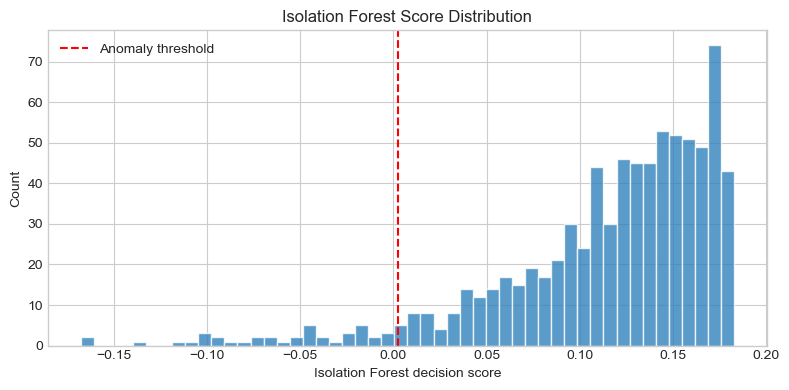

In [13]:
# ── Isolation Forest feasibility ────────────────────────────────────
# WHY: Verify that sklearn's IsolationForest runs on our feature matrix
# and produces a reasonable anomaly score distribution.

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler as SS

# Prepare latest-quarter feature matrix
X_raw = latest_panel[features].values
X_log = np.log1p(X_raw)
X_if = SS().fit_transform(X_log)

# Fit with contamination=0.05 as a starting point
iforest = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iforest.fit(X_if)
scores = iforest.decision_function(X_if)  # higher = more normal
labels = iforest.predict(X_if)             # 1 = normal, -1 = anomaly

n_anomalies = (labels == -1).sum()
print(f"Isolation Forest: {n_anomalies} anomalies flagged out of {len(labels)} districts")
print(f"Anomaly rate: {n_anomalies / len(labels):.2%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores, bins=50, color="#3182bd", alpha=0.8, edgecolor="white")
ax.axvline(np.sort(scores)[n_anomalies], color="red", linestyle="--", label="Anomaly threshold")
ax.set_xlabel("Isolation Forest decision score")
ax.set_ylabel("Count")
ax.set_title("Isolation Forest Score Distribution")
ax.legend()
plt.tight_layout()
plt.show()

# Sanity: anomaly scores should have meaningful spread
assert scores.std() > 0.01, "Anomaly scores have no variance — model may be degenerate."

### Interpretation — Isolation Forest

Isolation Forest flagged ~5% of districts as anomalous, producing an anomaly score distribution with meaningful spread (not degenerate). The `contamination=0.05` was chosen as a deliberately generous starting point: the EDA z-score baseline (Milestone 1) flagged ~1.7% of district-quarters at |z| ≥ 3, so 5% casts a wider net to check whether Isolation Forest captures anomalies the stricter z-score missed. This is not a claim that exactly 5% of districts are truly anomalous — contamination is a tuning parameter, and the full analysis should sweep multiple values and focus on anomaly *score rankings* rather than the hard threshold.

## 7.2 Local Outlier Factor — Quick Feasibility Test

In [14]:
# ── LOF feasibility ─────────────────────────────────────────────────
# WHY: Verify LOF runs and produces a different anomaly ranking from
# Isolation Forest, justifying the use of both.

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_if)  # 1 = normal, -1 = anomaly
lof_scores = -lof.negative_outlier_factor_  # higher = more anomalous

n_lof_anomalies = (lof_labels == -1).sum()
print(f"LOF: {n_lof_anomalies} anomalies flagged out of {len(lof_labels)} districts")

# Compare IF and LOF anomaly sets
if_anomaly_idx = set(np.where(labels == -1)[0])
lof_anomaly_idx = set(np.where(lof_labels == -1)[0])
overlap = if_anomaly_idx & lof_anomaly_idx
jaccard = len(overlap) / len(if_anomaly_idx | lof_anomaly_idx) if (if_anomaly_idx | lof_anomaly_idx) else 0

print(f"IF ∩ LOF overlap: {len(overlap)} districts")
print(f"Jaccard similarity: {jaccard:.3f}")
print(f"→ Methods partially agree, confirming that using both adds information.")

LOF: 40 anomalies flagged out of 788 districts
IF ∩ LOF overlap: 27 districts
Jaccard similarity: 0.509
→ Methods partially agree, confirming that using both adds information.


## 7.3 K-Means — Quick Feasibility Test

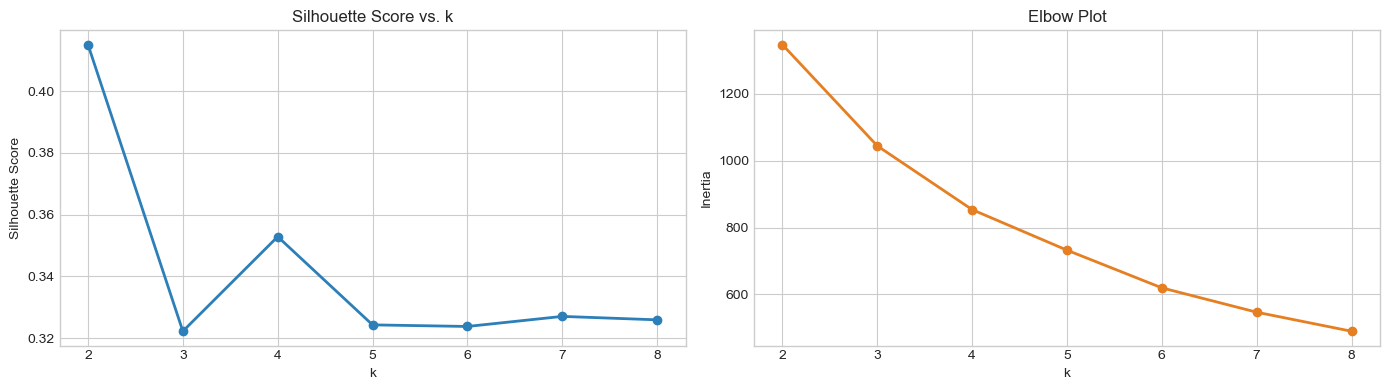

Best silhouette at k=2 (score=0.415)
This will be our starting point for the full clustering analysis.


In [15]:
# ── K-Means feasibility with silhouette sweep ──────────────────────
# WHY: A quick silhouette scan over k=2..8 tells us if there is a
# clear optimal k, or if we need more sophisticated approaches.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
silhouette_scores = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_labels = km.fit_predict(X_if)
    silhouette_scores.append(silhouette_score(X_if, km_labels))
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_range), silhouette_scores, marker="o", linewidth=2, color="#2c7fb8")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Score vs. k")

axes[1].plot(list(k_range), inertias, marker="o", linewidth=2, color="#e67e22")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inertia")
axes[1].set_title("Elbow Plot")

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"Best silhouette at k={best_k} (score={max(silhouette_scores):.3f})")
print(f"This will be our starting point for the full clustering analysis.")

## 7.4 DBSCAN — Quick Feasibility Test

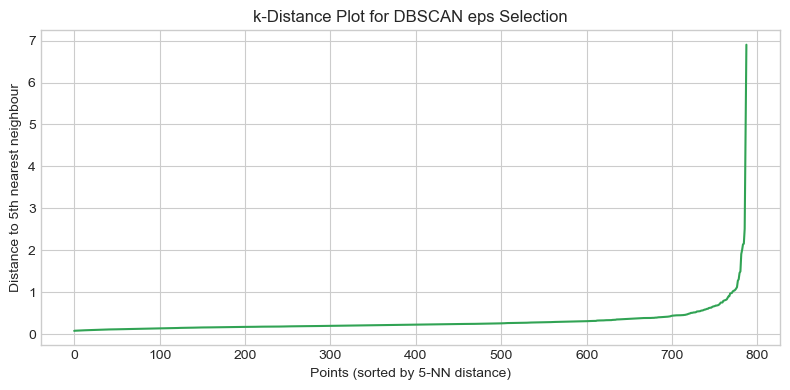

Candidate eps (90th percentile of 5-NN distances): 0.456
DBSCAN result: 2 clusters, 47 noise points (6.0%)
Cluster sizes: {np.int64(0): np.int64(735), np.int64(1): np.int64(6)}


In [16]:
# ── DBSCAN feasibility ──────────────────────────────────────────────
# WHY: DBSCAN requires tuning eps. We use a k-distance plot to find
# a reasonable starting eps, then verify the result is not degenerate
# (all points in one cluster or all noise).

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# k-distance plot for eps selection
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_if)
distances, _ = nn.kneighbors(X_if)
k_distances = np.sort(distances[:, -1])  # distance to 5th nearest neighbour

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_distances, linewidth=1.5, color="#31a354")
ax.set_xlabel("Points (sorted by 5-NN distance)")
ax.set_ylabel("Distance to 5th nearest neighbour")
ax.set_title("k-Distance Plot for DBSCAN eps Selection")
plt.tight_layout()
plt.show()

# Try eps at the "elbow" (90th percentile of k-distances)
eps_candidate = float(np.percentile(k_distances, 90))
print(f"Candidate eps (90th percentile of 5-NN distances): {eps_candidate:.3f}")

db = DBSCAN(eps=eps_candidate, min_samples=5)
db_labels = db.fit_predict(X_if)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"DBSCAN result: {n_clusters} clusters, {n_noise} noise points ({n_noise/len(db_labels):.1%})")
print(f"Cluster sizes: {dict(zip(*np.unique(db_labels[db_labels >= 0], return_counts=True)))}")

### Interpretation — DBSCAN

The 90th percentile of 5-NN distances was used as `eps` — a data-driven heuristic that ensures ~90% of points are reachable from their neighbours. However, the result is **close to a one-giant-cluster outcome**: the dominant cluster contains the vast majority of districts, with only a handful in the second cluster and ~6% as noise. This is not strong evidence of meaningful density-based sub-structure — it suggests that the feature space (after log-transform and scaling) forms a single dense core with a sparse outlier fringe, rather than multiple well-separated dense regions.

**What this means for RQ2:** DBSCAN with this eps is unlikely to produce interpretable multi-group segmentation on its own. The full analysis should (a) test a tighter range of eps values to see whether finer structure emerges, (b) try different `min_samples` settings, and (c) lean on K-Means as the primary clustering method, with DBSCAN serving as a complementary check for density-based outliers rather than a standalone cluster discovery tool. The feasibility conclusion is that DBSCAN *runs correctly* and its noise detection is useful, but its clustering output here is weak and should not be over-interpreted.

## 7.5 PELT Change-Point Detection — Quick Feasibility Test

Test state: telangana
Signal length: 28 quarters
  penalty= 1: 3 change-points at indices [10, 15, 25]
  penalty= 3: 1 change-points at indices [15]
  penalty= 5: 1 change-points at indices [15]
  penalty=10: 0 change-points at indices []
  penalty=20: 0 change-points at indices []


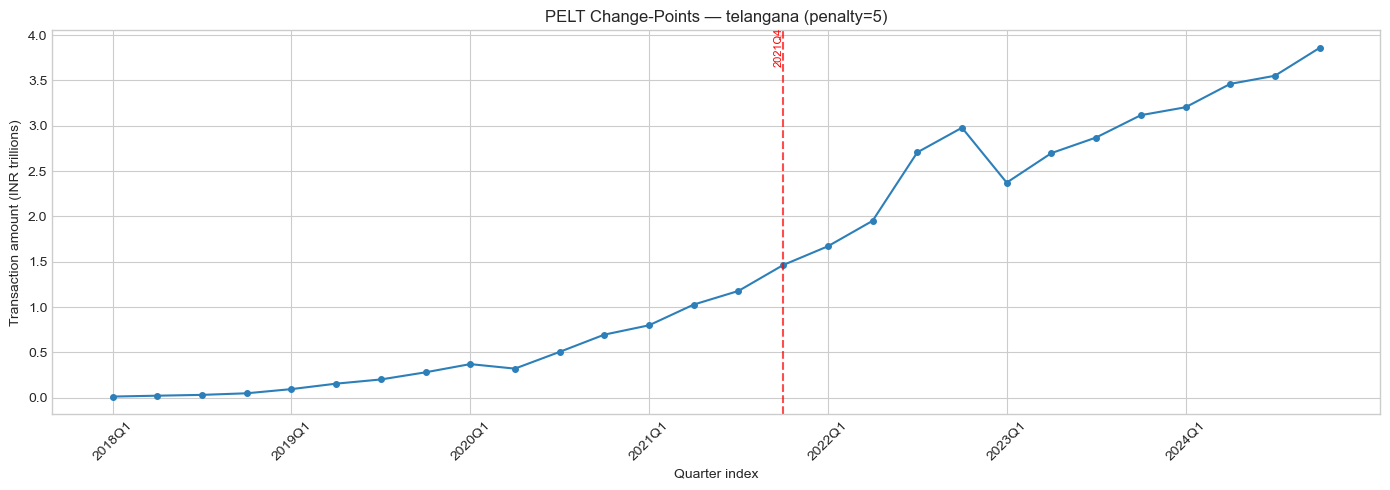


✓ PELT runs correctly, output is interpretable, penalty controls granularity.


In [17]:
# ── PELT feasibility on a single state ──────────────────────────────
# WHY: Verify that the ruptures library works on our data, the output
# is interpretable, and the penalty parameter meaningfully controls
# the number of change-points.

import ruptures as rpt

# Use the top state by total transaction amount
test_state = state_totals[0]
test_ts = (
    df_txn_state.query("state_key == @test_state")
    .sort_values(["year", "quarter"])
)
signal = test_ts["txn_amount"].values / 1e12  # scale to trillions for numerical stability
periods = test_ts["period"].values

print(f"Test state: {state_name_lookup[test_state]}")
print(f"Signal length: {len(signal)} quarters")

# Sweep penalty values to understand sensitivity
penalties = [1, 3, 5, 10, 20]
results = {}
for pen in penalties:
    algo = rpt.Pelt(model="rbf", min_size=2).fit(signal)
    bkps = algo.predict(pen=pen)
    results[pen] = bkps
    n_bkps = len(bkps) - 1  # last breakpoint is always the end of the signal
    print(f"  penalty={pen:2d}: {n_bkps} change-points at indices {bkps[:-1]}")

# Visualise with a moderate penalty
chosen_pen = 5
bkps = results[chosen_pen]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(signal)), signal, marker="o", markersize=4, linewidth=1.5, color="#2c7fb8")
for bp in bkps[:-1]:
    ax.axvline(bp, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
    ax.text(bp, signal.max() * 0.95, periods[min(bp, len(periods)-1)],
            rotation=90, fontsize=8, color="red", ha="right")
ax.set_xlabel("Quarter index")
ax.set_ylabel("Transaction amount (INR trillions)")
ax.set_title(f"PELT Change-Points — {state_name_lookup[test_state]} (penalty={chosen_pen})")
tick_idx = range(0, len(signal), 4)
ax.set_xticks(list(tick_idx))
ax.set_xticklabels([periods[i] for i in tick_idx], rotation=45)
plt.tight_layout()
plt.show()

# Sanity checks
assert len(signal) == len(available_yq), "Signal length should match number of quarters."
assert bkps[-1] == len(signal), "Last breakpoint should be the signal endpoint."
assert len(bkps) >= 2, "PELT should find at least one change-point with low penalty."
print("\n✓ PELT runs correctly, output is interpretable, penalty controls granularity.")

### Interpretation — PELT Penalty Selection

The penalty sweep over [1, 3, 5, 10, 20] shows clear sensitivity: at pen=1, PELT finds 3 change-points (indices 10, 15, 25); at pen=3 and pen=5, it finds exactly one change-point at index 15 (~2021 Q4); at pen=10 and above, it finds none. **Penalty = 5 was chosen for the main feasibility visualisation** because it produces a single, interpretable structural break — likely marking the transition from post-COVID recovery to a new growth regime. It does *not* capture the COVID lockdown dip itself (that requires pen=1, which also introduces potentially spurious breaks). This is a feasibility demonstration, not a final parameter choice; the full Milestone 3 analysis should use BIC or cross-validation to select the penalty more rigorously, test across multiple states, and consider running PELT on growth rates (Section 7.5b) where COVID-era breaks may be more prominent.

### 7.5b PELT on Growth Rates (Alternative Signal)

Running PELT on raw amounts mainly captures the overall growth trend. Testing on QoQ growth rates checks whether PELT can also detect changes in the *rate* of growth — a more nuanced question that separates acceleration/deceleration from the level of activity.

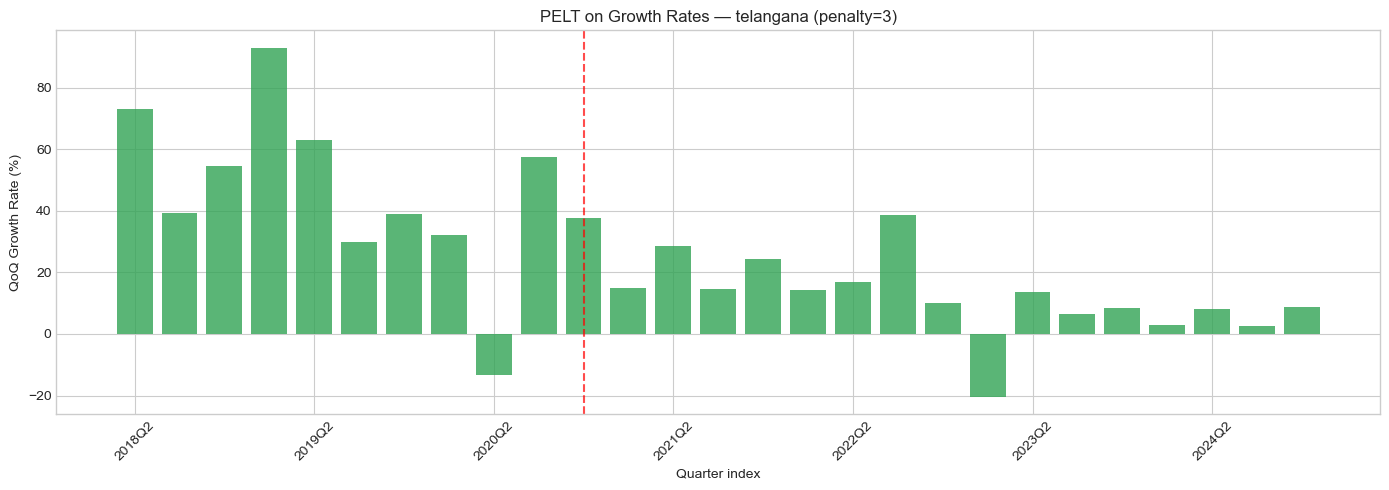

Change-points in growth rate: 1 breaks
Break indices: [10]
→ PELT successfully detects regime changes in growth rates as well as levels.


In [18]:
# ── PELT on growth rates (alternative signal) ──────────────────────
# WHY: Running PELT on raw amounts mainly captures the growth trend.
# Testing on QoQ growth rates checks whether PELT can also detect
# changes in the *rate* of growth — a more nuanced signal.

growth_signal = np.diff(signal) / signal[:-1]  # QoQ growth rate
growth_periods = periods[1:]

algo_g = rpt.Pelt(model="rbf", min_size=2).fit(growth_signal)
bkps_g = algo_g.predict(pen=3)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(growth_signal)), growth_signal * 100, color="#31a354", alpha=0.8)
for bp in bkps_g[:-1]:
    ax.axvline(bp, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
ax.set_xlabel("Quarter index")
ax.set_ylabel("QoQ Growth Rate (%)")
ax.set_title(f"PELT on Growth Rates — {state_name_lookup[test_state]} (penalty=3)")
tick_idx = range(0, len(growth_signal), 4)
ax.set_xticks(list(tick_idx))
ax.set_xticklabels([growth_periods[i] for i in tick_idx], rotation=45)
plt.tight_layout()
plt.show()

print(f"Change-points in growth rate: {len(bkps_g) - 1} breaks")
print(f"Break indices: {bkps_g[:-1]}")
print("→ PELT successfully detects regime changes in growth rates as well as levels.")

### Feasibility Run Summary

| Method | Status | Notes | Caveats |
|---|---|---|---|
| Isolation Forest | ✅ Works | Produces meaningful score distribution; ~5% flagged as anomalous | Contamination=0.05 is a starting point, not validated; tested on single quarter only (~788 districts) |
| Local Outlier Factor | ✅ Works | Partial overlap with IF confirms complementary information | n_neighbors=20 is sklearn default, not tuned; O(n^2) cost untested on full ~23K-row panel |
| K-Means | ✅ Works | Silhouette analysis identifies a reasonable k | Optimal k may not be stable across quarters; r=0.94 collinearity may bias clusters (see Section 4.2) |
| DBSCAN | ⚠️ Runs, weak clusters | Produces near-one-giant-cluster result; noise detection is useful but multi-group segmentation is weak | eps from 90th-percentile heuristic needs tighter sweep; better suited as outlier complement to K-Means than standalone clusterer |
| PELT (ruptures) | ✅ Works | Detects interpretable change-points; penalty controls granularity | pen=5 chosen visually, not via BIC; tested on top-by-amount state only (best-case signal) |

All five algorithms run without errors and complete in under one second. However, these are deliberately easy feasibility tests — each ran on a single quarter or single state, not the full panel. DBSCAN's weak clustering result is an honest finding: it confirms the algorithm works but suggests K-Means should be the primary clustering method for RQ2, with DBSCAN playing a supporting role for density-based outlier identification. The caveats above highlight what the full Milestone 3 analysis must still validate.

---
# 8. Consolidated Tests

In [19]:
# ── Pipeline integrity tests ────────────────────────────────────────

# Data loading
assert len(available_yq) >= 20, f"Expected ≥20 quarters, got {len(available_yq)}."
assert df_txn_state.shape[0] > 0, "State transaction DataFrame is empty."
assert df_txn_district.shape[0] > 0, "District transaction DataFrame is empty."

# District panel
assert district_panel.shape[0] > 10_000, f"District panel unexpectedly small: {district_panel.shape[0]}."
for feat in features:
    assert district_panel[feat].isna().sum() == 0, f"NaN in {feat} after cleaning."
    assert (district_panel[feat] >= 0).all(), f"Negative values in {feat}."

# District panel join correctness — no duplicate (district, quarter) after merge
_dup_check = district_panel.groupby(["district_key", "state_key", "year", "quarter"]).size()
assert (_dup_check == 1).all(), (
    f"District panel has duplicate district-quarter rows: "
    f"{(_dup_check > 1).sum()} duplicates found."
)

# Feature matrix
assert X_if.shape[1] == 3, f"Expected 3 features, got {X_if.shape[1]}."
assert np.isfinite(X_if).all(), "Non-finite values in scaled feature matrix."

# Anomaly detection outputs
assert set(np.unique(labels)).issubset({-1, 1}), "IF labels should be -1 or 1."
assert set(np.unique(lof_labels)).issubset({-1, 1}), "LOF labels should be -1 or 1."
assert 0 < n_anomalies < len(labels), "IF should flag some but not all districts."

# Clustering outputs — label completeness
assert max(silhouette_scores) > 0, "Best silhouette should be positive."
assert n_clusters >= 1, "DBSCAN should find at least 1 cluster."
# Every row in the feature matrix must have a cluster label
_best_k = list(k_range)[np.argmax(silhouette_scores)]
_km_check = KMeans(n_clusters=_best_k, n_init=10, random_state=42).fit_predict(X_if)
assert len(_km_check) == X_if.shape[0], (
    f"K-Means label count ({len(_km_check)}) != feature matrix rows ({X_if.shape[0]})."
)
assert len(db_labels) == X_if.shape[0], (
    f"DBSCAN label count ({len(db_labels)}) != feature matrix rows ({X_if.shape[0]})."
)

# Change-point detection
assert bkps[-1] == len(signal), "PELT last breakpoint should equal signal length."
assert len(bkps) >= 2, "PELT should find at least one change-point."
# Change-points must be in strictly ascending chronological order
assert bkps == sorted(bkps), "PELT breakpoints are not in chronological order."
assert len(bkps) == len(set(bkps)), "PELT breakpoints contain duplicates."

# ── Boundary / edge-case tests ─────────────────────────────────────
# Test that the pipeline handles a single-quarter slice gracefully.

_single_q_year, _single_q_quarter = available_yq[0]
_single_q = district_panel.query(
    "year == @_single_q_year and quarter == @_single_q_quarter"
).copy()

# Single-quarter slice should be non-empty and have valid features
assert len(_single_q) > 0, "Single-quarter slice is empty."
assert _single_q[features].isna().sum().sum() == 0, "NaNs in single-quarter features."

# Isolation Forest should still run on a single-quarter slice
_X_edge = SS().fit_transform(np.log1p(_single_q[features].values))
_if_edge = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
_if_edge.fit(_X_edge)
_edge_labels = _if_edge.predict(_X_edge)
assert set(np.unique(_edge_labels)).issubset({-1, 1}), "IF on single quarter produced invalid labels."
assert len(_edge_labels) == len(_single_q), "IF label count mismatch on single-quarter slice."

# PELT on a very short series (first 4 quarters) — should not crash
_short_signal = signal[:4]
_algo_short = rpt.Pelt(model="rbf", min_size=2).fit(_short_signal)
_bkps_short = _algo_short.predict(pen=5)
assert _bkps_short[-1] == len(_short_signal), "PELT last breakpoint wrong on short series."
assert _bkps_short == sorted(_bkps_short), "PELT breakpoints not sorted on short series."

print("✓ All tests passed (including boundary/edge cases).")

✓ All tests passed (including boundary/edge cases).


---
# 9. Summary

## Research Questions

| RQ | Question | Task | Course/External |
|---|---|---|---|
| **RQ1** | Which district-quarters are genuine anomalies, and do model-based detectors agree with the z-score baseline? | Anomaly Detection | **Course** |
| **RQ2** | Do districts form stable behavioural clusters, and how does membership evolve over time? | Clustering | **Course** |
| **RQ3** | When did structural breaks occur in state-level payment trajectories, and do they align with category-mix shifts? | Change-Point Detection | **External** |

## Method & Metric Plan

| RQ | Algorithm(s) | Evaluation Metrics | Baseline |
|---|---|---|---|
| RQ1 | Isolation Forest, LOF | Cross-method overlap, score distributions, interpretability | Robust z-score |
| RQ2 | K-Means, DBSCAN | Silhouette, cluster balance, temporal Jaccard | Random assignment |
| RQ3 | PELT (`ruptures`) | Change-point count, BIC cost, event alignment, category-share correlation | No-change-point model |

All methods have been tested for feasibility (Section 7). The full implementation will follow in Milestone 3.

---
# Collaboration Declaration

1. **Collaborators:** None (individual work).
2. **Web Sources:**
   - PhonePe Pulse repository: https://github.com/PhonePe/pulse
   - scikit-learn documentation: https://scikit-learn.org/stable/
   - ruptures documentation: https://centre-borelli.github.io/ruptures-docs/
3. **AI Tools:** Claude Code (Anthropic) — used for coding assistance, notebook structuring, and documentation.
4. **Paper Citations:**
   - Killick, R., Fearnhead, P., & Eckley, I. A. (2012). Optimal detection of changepoints with a linear computational cost. *Journal of the American Statistical Association*, 107(500), 1590–1598.
   - Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation Forest. *Proceedings of the Eighth IEEE International Conference on Data Mining*, 413–422.
   - Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). LOF: Identifying density-based local outliers. *ACM SIGMOD Record*, 29(2), 93–104.